# 0.2 · The PD prior

*0. General · notebook 0.2 of the story.* ← [0.1 · the real credit data](<0.1_data_exploration.ipynb>) · [0.3 · the LGD prior](<0.3_prior_visualisation_lgd.ipynb>) →

**What does our credit prior generate for PD, how does it differ from TabICL's own, and does it look
like the real books of 0.1?** Experiment 1 then trains on both and lets the benchmark decide; this
notebook checks beforehand that the prior produces what it claims.

- **Original** is the prior at `credit_fraction = 0` — TabICLv2's `graph_scm`, unchanged, and
  Experiment 1's control. **Credit** is ours, at `credit_fraction = 1`.
- Both are drawn live from `config/Exp1_PD.yaml` through `TaskGenerator`, the code path training
  uses, with the settings of the sweep's first arm: filter mode `tabicl` and the mild default
  correlation, ρ in [0.03, 0.12]. Every generated table has 1,024 rows and is zero-padded to 100
  columns, of which 1 to 100 carry features.
- **How our PD target is built in this experiment.** The config runs the target in `mechanism`
  mode: three hard threshold rules are added to the causal graph's output, then a Merton/Vasicek
  one-factor model draws the task's long-run default rate uniformly from [2 %, 30 %] and lets one
  systematic factor per cohort (1 to 12 cohorts) move the realised rate around it. In this mode the
  config's target-level `base_rate_range`, its label-flip rates and its `selection` block are not
  read — they belong to `quantile` mode. Shifts between the context and the rows to predict, and
  missing values that depend on the outcome, are added on top.
- **A caveat on reproducibility.** PD draws are not identical from one run to the next, even at a
  fixed seed: the upstream graph code builds its feature groups from a Python `set`, whose order
  follows the per-process string hash. The numbers below are therefore quoted to the precision that
  survives a rerun; the exact values of a run are in its printed summary. (The column order of our
  own tables changes too, for a different reason: our generator shuffles columns with torch's
  global random generator, which is not seeded here.)

**The order.** **A** puts the target of both priors against the real books: the base rate, then
whether defaults cluster. **B** takes the credit mechanisms one at a time: correlated defaults,
distribution shift, informative missingness. **C** judges the task as a whole: how predictable it is
next to real data (and what the filter keeps), what one table looks like, and how its features depend
on each other.

## Grounding in the literature

PD is imbalanced binary classification. In TabICLv2's `graph_scm` the class label is made inside the
causal graph, and imbalance enters only through the categorical converter's bias
(`repositories/NanoTabICL.txt` `rand_converter`; `TabICL.txt` `CategoricalConverter`; paper §E.6) —
nothing there aims at a credit-like rare rate. O'Prior finds that the diversity of the generating
mechanisms, more than realism, drives transfer (`papers/2026/05_Bouadi_ShapingThePrior` Table 2), so
the realism checks below are a sanity check, not the claim. **Outside the library:** the
Merton/Vasicek one-factor model and the Basel IRB asset correlations behind the correlated-default
mechanism are credit-risk knowledge that `tfm-library` does not contain (a whole-library search
returns nothing); they are cited as such and never attributed to a TFM paper. Pin `e5ce016`.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib
ROOT = pathlib.Path.cwd()
# Walk up to the repository root — the notebook may be opened from its chapter folder, from
# notebooks/, or from the root — then work FROM the root, so relative paths (config/...) resolve
# exactly as under `python -m src.utils.run_notebooks`.
while not (ROOT / "src" / "visualize").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.visualize import exp1_plots as e1, figures, pool_plots as pp, mechanism_plots, prior_plots, style, summaries, literature

style.apply()
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK   = "pd"
CONFIG = "config/Exp1_PD.yaml"   # Exp1 is the prior sweep, so it is the one to visualise
N      = 500     # tasks drawn per prior

# Clears THIS notebook's figure folder — and no other — before anything is drawn.
FIGS = figures.FigureSaver("0.2_prior_visualisation_pd")

## Loading the two priors and the real data

Pre-generated pools when they are on disk, otherwise 500 tasks per prior generated live — the printed
`source` says which. The real PD datasets of 0.1 are loaded alongside, so that every
comparison below is against them.

In [2]:
variants = pp.discover_pools(TASK)
print("pools found:", ", ".join(variants) if variants else "none - generating live")
loaded, SOURCE = pp.load_variants_or_generate(TASK, n=N, seed=0, config=CONFIG)
print("source =", SOURCE, "|", {k: len(v) for k, v in loaded.items()})

REAL = summaries.load_real_datasets(TASK)
print(f"real {TASK.upper()} datasets loaded: {len(REAL)}")
REFERENCE = pp.real_reference(TASK)

pools found: none - generating live
no pools found for pd — generating 500 datasets per arm live from config/Exp1_PD.yaml
source = live | {'original': 500, 'credit': 500}
real PD datasets loaded: 14
reference: measured from 14 real PD datasets


## A · Does the target look like real PD data?

### A1 · The two priors in numbers

Per prior: the table size (rows are always 1,024; features counts only the columns that vary, the
rest is zero padding), and the base rate — mean, 10th and 90th percentile, and the share of tasks
below 5 %.

In [3]:
pp.variant_summary(loaded, TASK)

,variant,n_sampled,rows_median,features_median,features_range,base rate mean,base rate p10,base rate p90,below 5%
0,original,500,1024,51,3-98,0.5181,0.1942,0.8380,0.016
1,credit,500,1024,84,12-100,0.1522,0.0391,0.2705,0.140


### A2 · Which base rates does each prior generate?

**What it shows.** A histogram of the default rate of each generated task, 500 per prior, over 40 bins; the strip underneath marks the 14 real datasets' rates. The dotted line is 50 %, the dashed one Tanna 2026's 10 %.

**Why it matters.** The base rate is the property of a PD task a model adapts to first. A model that has only seen balanced tasks has never met a 7 % book, and below 10 % is where a classifier collapses to predicting no defaults (0.1 A1).

**What it says.** The original prior spreads its tasks over almost the whole range — about 2 % to 99 %, median 50 % — with only 3–4 % of tasks below 10 %. Ours generates about 2 % to 41 %, median 15 %, and puts about 30 % of its tasks below 10 %. Every real rate (6.7 %–40 %) falls inside our prior's range, and for 12 of the 14 books at least a tenth of our tasks lie within 5 points of it; for the original prior that holds for only 3 to 5.

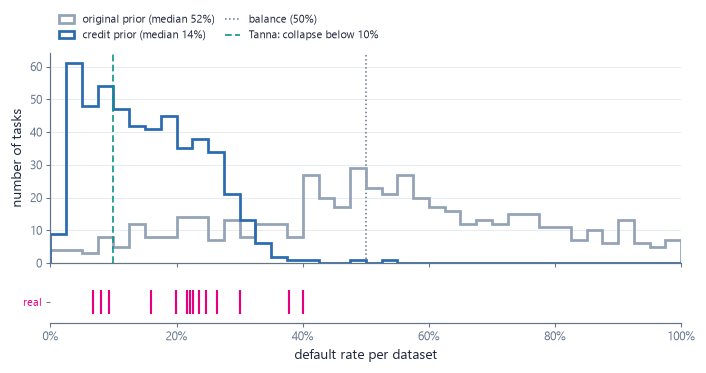

In [4]:
FIGS.save(pp.plot_target_comparison(loaded, TASK, reference=REFERENCE), "base_rate_by_variant",
    caption="Distribution of the default rate per generated task for the original and the credit prior, 500 tasks each, as step histograms over 40 bins; the strip below marks the 14 real PD datasets, the dotted line a 50% rate and the dashed line the 10% threshold of Tanna 2026.");

### A3 · Do defaults cluster, as real ones do?

**What it shows.** Left: for every task, how much the default rate varies between twelve contiguous blocks of rows, divided by the variation independent rows would give (1 = independent); violins for the two priors, stars for the real datasets. Right: the default rate block by block for one task of each prior and two real books.

**Why it matters.** Real defaults arrive in waves: a downturn raises every borrower's risk at once, so a book's default rate varies between cohorts more than coin flips would. The Vasicek factor is our prior's mechanism for it. The model itself cannot see row order inside a table, so this clustering reaches it only through the cohort shift of B2, where context and query come from different cohorts.

**What it says.** The original prior sits at a ratio of about 1 — independent rows. Ours has a median of about 1.3 and a tail to about 5. The real datasets spread from about 0.6 to 9.8, about half of them between 1 and 2. A caveat on the real side: their rows are in file order, which need not be time order, so a ratio above 1 there means only that the file is ordered by something that moves the default rate.

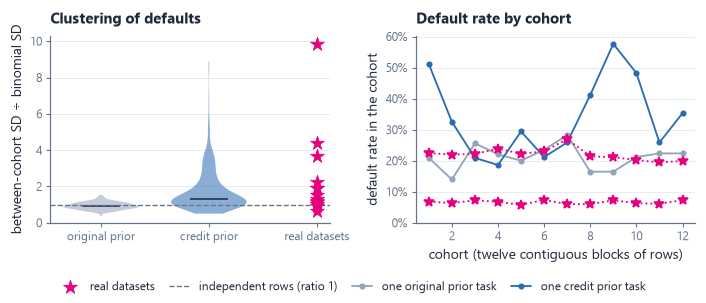

In [5]:
FIGS.save(e1.plot_default_clustering(loaded, REAL), "default_clustering",
    caption="Left: between-cohort standard deviation of the default rate divided by its binomial standard error under independence, one violin per prior and stars for the real datasets, the dashed line at the independence value of 1. Right: default rate per cohort, twelve contiguous blocks of rows, for one task of each prior and two real datasets.");

## B · The credit mechanisms, one at a time

Each figure switches one mechanism of our prior on alone, generated live from the same config.

### B1 · Correlated defaults — the Vasicek factor

**What it shows.** Left: the realised default rate of 80 tasks whose target rate is fixed at 15 %, under the mild (ρ in [0.03, 0.12]) and the aggressive (ρ in [0.12, 0.30]) asset correlation. Right: the spread of the realised rate at five fixed values of ρ, with the Basel IRB corporate cap of 0.24 — external domain knowledge.

**Why it matters.** ρ is Experiment 1's PD intensity lever: how strongly one shared factor moves the whole book, and so how far a year's default rate strays from the long-run rate. The aggressive range reaches 0.30 = 0.24 × 1.25, the Basel III multiplier for large financial institutions (`config/Exp1_PD.yaml`).

**What it says.** The realised rate scatters around the 15 % target in both settings; the aggressive one widens the scatter by about half (a standard deviation of roughly 0.04 against 0.03), and the spread grows steadily with ρ, from about 0.022 at ρ = 0.03 to 0.043 at ρ = 0.30. It is a real but modest lever.

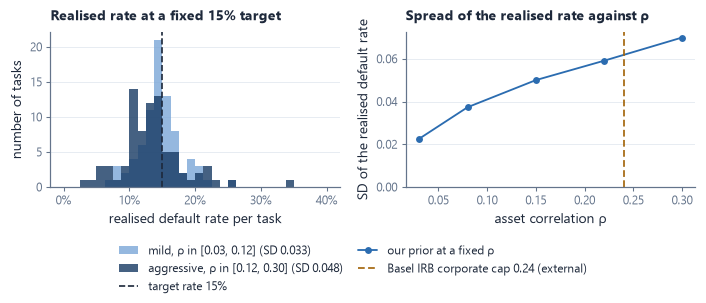

In [6]:
FIGS.save(mechanism_plots.correlated_defaults(CONFIG, n=80), "correlated_defaults",
    caption="Left: histogram of the realised default rate over 80 generated tasks with the target rate fixed at 15%, under mild and aggressive asset correlation, standard deviations in the legend. Right: standard deviation of the realised rate against the asset correlation rho at five values, with the Basel IRB corporate cap of 0.24 dashed.");

### B2 · Distribution shift — does the query look like the context?

**What it shows.** For each kind of shift, one point per generated task: the default rate in its context rows (the rows the model conditions on) against the rate in its query rows (the rows it must predict). Blue tasks have the shift switched on; grey ones are the same prior without it. On the dashed line the two parts are alike. For the covariate shift the axes show one feature, in standard deviations.

**Why it matters.** Real deployment is never i.i.d.: a scorecard fitted on past loans scores next quarter's applicants, and TFMs lose ground off the i.i.d. regime (`papers/2026/06_Purucker_BeyondIID`). Each kind is one credit failure mode — later vintages (cohort), a different applicant mix (covariate), a moved default rate (prior probability), and reject inference (selection): the context holds only the approved, lower-risk book while the query reaches into the applicants the screen turned away. That last mechanism follows Klein & Hoffart 2026, a position paper without experiments (`papers/2026/01_Klein_Hoffart`).

**What it says.** The covariate and selection shifts are strong and consistent — every selection task has a riskier query, by about 0.3 on average. The cohort shift cannot be told apart from no shift (a mean context–query gap of about 0.04 with it or without it): at mild ρ the vintage blocks it relies on barely differ. The prior-probability shift is one-sided: in about nine tasks out of ten the query's default rate is lower, and in about four out of five the query has under 1 % defaults, because with so few defaults per table the context absorbs nearly all of them. So in practice it teaches that a query may hold no defaults at all, not that the rate can move either way — a behaviour of the prior code, reported here rather than changed.

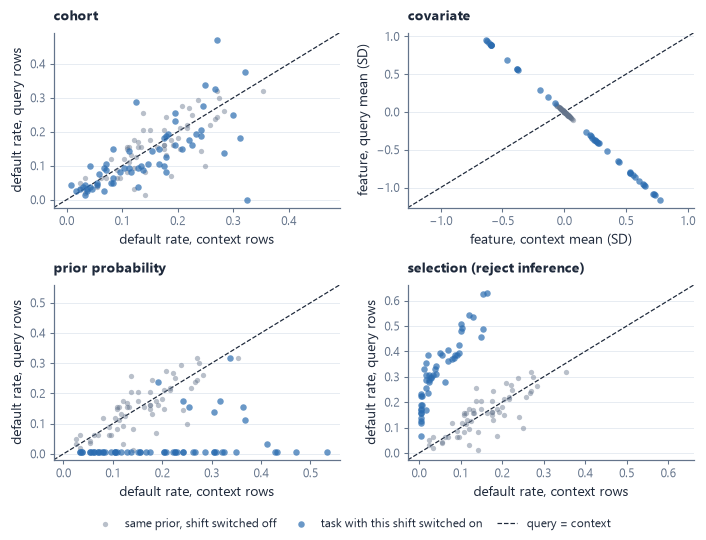

In [7]:
FIGS.save(mechanism_plots.shift_kinds(CONFIG, n=60), "shift_kinds",
    caption="Context against query mean per generated task, one panel per shift kind (cohort, covariate, prior probability, selection), 60 tasks with the shift switched on and 60 without; default rates for the target shifts, the shifted feature in standard deviations for the covariate shift, and the dashed line where query equals context.");

### B3 · Informative missingness — is a missing value a signal?

**What it shows.** The share of values missing among non-defaulters and among defaulters, when the missing values are placed completely at random (coupling 0) and when their probability rises with the outcome (coupling 2), on a controlled table of 4,000 rows with a 20 % base rate and 20 % of values missing.

**Why it matters.** A thin credit file is itself a risk signal. TabICLv2 mean-imputes missing values away at inference (`repositories/TabICL.txt` `TransformToNumerical`); O'Prior models values missing not at random explicitly (`papers/2026/05_Bouadi_ShapingThePrior` §2.2) — the mechanism reproduced here. The Exp1 config uses coupling 1.0 on 30 % of the columns, 5–35 % missing each, plus a was-missing indicator column.

**What it says.** At coupling 2 about 3 % of a non-defaulter's values are missing against about 66 % of a defaulter's; at random the share is 20 % for both. The outcome can be read off the missingness pattern — exactly the signal mean imputation discards.

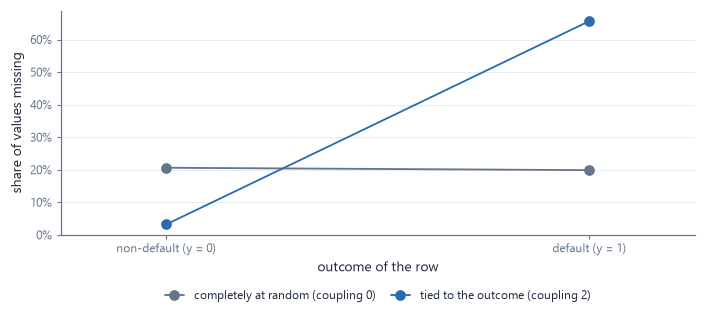

In [8]:
FIGS.save(mechanism_plots.informative_missingness(TASK), "informative_missingness",
    caption="Share of values missing for non-defaulters and defaulters on a controlled table of 4,000 rows, under missingness completely at random (coupling 0) and missingness tied to the outcome (coupling 2).");

## C · Is it the right task?

### C1 · How predictable are the tasks, next to real data?

**What it shows.** Every task's predictability measured by the predictability filter itself: the out-of-bag pseudo-R² of a 25-tree ExtraTrees (`src/prior/filters.py` `predictability`, mirroring `repositories/TabICL.txt` `should_filter`). One row each for 120 unfiltered tasks of each prior and for the real datasets (each scored on three random 1,024-row samples, averaged). The shaded band is what the `banded` filter keeps, [0.02, 0.30]; a hollow point is a task the `tabicl` filter rejects (bootstrap p ≥ 0.05); `off` keeps everything.

**Why it matters.** A prior teaches the difficulty it generates. Real credit data carries little signal; a prior of easy tasks teaches the model to trust its features more than credit data allows. The filter mode is Experiment 1's second lever, and TabICLv2 reports that its filter rejects about a third of classification tasks and helps convergence (`papers/2026/02_Qu_TabICLv2` §Data filtering, Fig. 10).

**What it says.** The real PD datasets are hard: median pseudo-R² about 0.06, twelve of the fourteen at or below 0.2, half inside the band; only `hmeq` passes 0.4. The original prior's tasks split in two — about a third with no detectable signal (the ones `tabicl` rejects) and a spread of easier ones up to 1 — so its median jumps between the two groups from run to run. Ours are consistently predictable: almost all between 0.3 and 0.95, median about 0.6, a few percent inside the band and almost none rejected. The exact numbers are printed in the summary. So our PD prior sets tasks much more predictable than real default data — a candidate explanation for the credit-fraction-1 arms' lower development ROC-AUC in 1.1, not a tested one.

In [9]:
SCORES = mechanism_plots.predictability_scores(CONFIG, REAL, n=120)

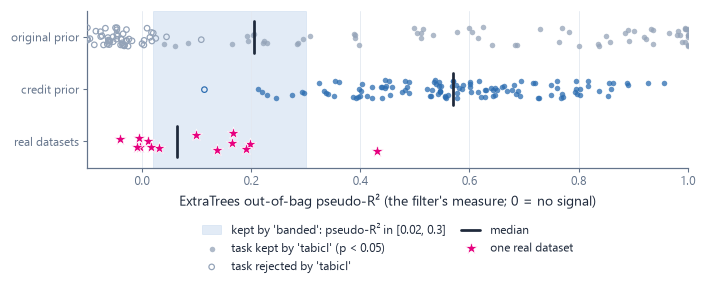

In [10]:
FIGS.save(mechanism_plots.plot_predictability(SCORES, CONFIG), "predictability",
    caption="ExtraTrees out-of-bag pseudo-R² per task for 120 unfiltered tasks of each prior and per real PD dataset (mean over three 1,024-row samples), with each row's median; the shaded band marks the range kept by the banded filter and hollow points the tasks rejected by the tabicl filter at p of 0.05 or more.");

### C2 · What does the model actually read?

**What it shows.** Twelve random rows of one generated task and of one real dataset (`gmsc`): the seven columns with the most distinct values plus the target, each column scaled to its own range.

**Why it matters.** Summary statistics can match while the tables themselves look nothing alike; this is the input the model reads, row by row.

**What it says.** The generated columns spread their rows over the whole range. The real ones are skewed — most rows sit at one end of a column with a few far out, as counts of late payments do — and the real target is almost all zeros. Our prior does not reproduce such count-like, one-sided columns. (Which generated columns appear varies from run to run; see the reproducibility caveat at the top.)

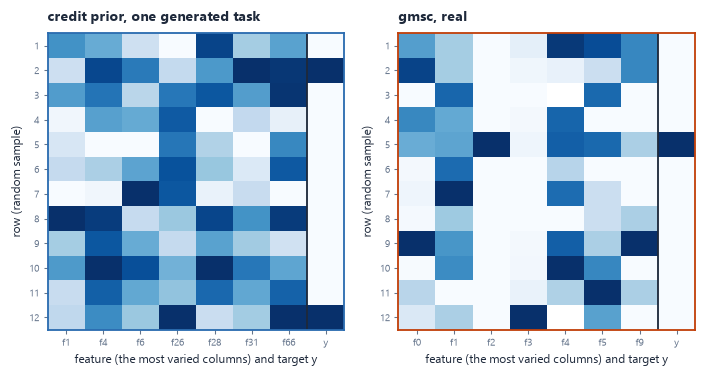

In [11]:
_name, _real_one = next(iter(REAL.items())) if REAL else (None, None)
FIGS.save(e1.plot_side_by_side_tables(loaded["credit"][0], _real_one, task=TASK, real_name=_name and _name.split(".", 1)[-1]), "side_by_side_tables",
    caption="Twelve random rows of one generated credit-prior task and of one real PD dataset as heatmaps, the seven most varied columns plus the target separated by a vertical rule, each column min-max scaled to its own range.");

### C3 · How strongly do the features depend on each other?

**What it shows.** The eigenvalues of each table's feature-correlation matrix, divided by the largest, against their rank divided by the number of columns: faint lines single tables, bold lines the medians. Generated tables are measured on the columns that vary (the zero padding removed); a real table wider than 100 columns on a random 100.

**Why it matters.** O'Prior's central realism measure. A curve that falls steeply means a few directions carry most of the variance — strongly shared structure; a flat one means nearly independent columns.

**What it says.** Both priors fall steeply and almost coincide: our credit mechanisms leave the feature structure much as TabICL's causal graphs make it. The real datasets fall far more slowly — their variance is spread over many directions (0.1 B4). On this measure both priors generate more strongly dependent features than real credit tables have, a gap neither closes.

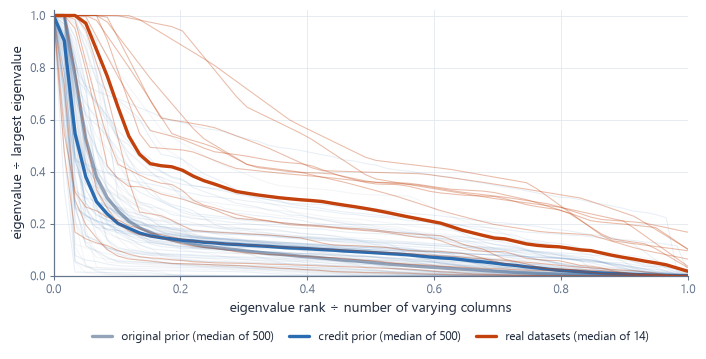

In [12]:
FIGS.save(pp.plot_spectrum_by_variant(loaded, real=REAL), "spectrum_by_variant",
    caption="Eigenvalue spectra of the feature correlation matrix, each normalised by its largest eigenvalue and plotted against eigenvalue rank over the number of varying columns, for 40 generated tasks per prior and every real PD dataset; bold lines are medians.");

## Summary

The priors in text: the two priors against the real base rates (A1–A2), then the predictability of
their tasks next to the real datasets (C1). Printed last, so `output/All_Results.md` carries the
numbers, followed by the `tfm-library` sources cited (pin `e5ce016`) and the list of figures.

In [13]:
print(summaries.prior_summary(loaded, TASK, source=SOURCE, reference=REFERENCE, config=CONFIG))
print()
print(mechanism_plots.predictability_summary(SCORES, CONFIG))
print()
print(literature.references_md(["imbalance_source", "tanna_paradox", "hc_base_rate", "oprior_headline", "oprior_creditg", "klein_rule", "tabicl_impute", "filter_rate_clf", "filter_pval", "filter_extratrees_n", "merton_vasicek", "basel_corp"]))
print()
print(FIGS.summary())


PRIOR SUMMARY — PD
data source      : live  ('pool' = the files training reads; 'live' = generated on the fly now)
variants compared: original, credit
datasets sampled : original=500, credit=500

--- PER VARIANT --------------------------------------------------------------

original:
  shape          rows 1024 to 1024 (median 1024) | varying features 3 to 98 (median 51) (padded to 100)
  base rate      0.4% to 99.2% (median 52.0%)
  below 5%       1.6% of datasets
  below 10%      3.8% of datasets

credit:
  shape          rows 1024 to 1024 (median 1024) | varying features 12 to 100 (median 84) (padded to 100)
  base rate      1.9% to 53.1% (median 14.2%)
  below 5%       14.0% of datasets
  below 10%      34.4% of datasets

--- AGAINST THE REAL DATASETS ------------------------------------------------
real base rate: algorithmwatch=37.8%, bank_status=22.6%, cobranded=24.6%, german=30.0%, gmsc=6.7%, hackerearth=23.6%, hmeq=19.9%, home_credit=8.1%, lendingclub=16.0%, loan_default=9.3%